<a href="https://colab.research.google.com/github/NguyenTNgan/spatial-temporal-defect-segmentation/blob/main/notebooks/thermal_dataset_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
ZIP_PATH="/content/drive/MyDrive/Suzlon/Thermal Inspection Dataset for Defect Segmentation in CFRP Laminates.zip"

BASE="/content/dataset"
ORIGINAL="/content/original"
ANNOTATED="/content/annotated"


!rm -rf /content/dataset /content/original /content/annotated
!mkdir -p /content/dataset

!unzip -q "$ZIP_PATH" -d /content/dataset

import glob

orig_zip = glob.glob(BASE + "/**/originalData.zip", recursive=True)[0]
ann_zip  = glob.glob(BASE + "/**/annotatedData.zip", recursive=True)[0]

print("Original ZIP:", orig_zip)
print("Annotated ZIP:", ann_zip)


!mkdir -p /content/original /content/annotated

!unzip -q "$orig_zip" -d /content/original
!unzip -q "$ann_zip" -d /content/annotated

Original ZIP: /content/dataset/Thermal Inspection Dataset for Defect Segmentation in CFRP Laminates/originalData.zip
Annotated ZIP: /content/dataset/Thermal Inspection Dataset for Defect Segmentation in CFRP Laminates/annotatedData.zip


In [3]:
import os
import shutil
import cv2
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim

In [4]:
# Clean old flatten folders

shutil.rmtree('/content/original_flat', ignore_errors=True)
shutil.rmtree('/content/annotated_flat', ignore_errors=True)

print('Old flat folders deleted.')

# Remove MacOS junk files
def flatten(src, dst):

    os.makedirs(dst, exist_ok=True)

    copied = 0

    for root, _, files in os.walk(src):

        if '__MACOSX' in root:
            continue

        for f in files:

            if f.startswith('._'):
                continue

            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif')):

                src_path = os.path.join(root, f)
                dst_path = os.path.join(dst, f)

                shutil.copy(src_path, dst_path)

                copied += 1

    print(f'Copied {copied} files from {src}')

# Flatten datasets
flatten('/content/original', '/content/original_flat')
flatten('/content/annotated', '/content/annotated_flat')

# File counts
original_files = os.listdir('/content/original_flat')
annotated_files = os.listdir('/content/annotated_flat')

print('\nDataset counts')
print('Original flat:', len(original_files))
print('Annotated flat:', len(annotated_files))

print('\nSample original:', original_files[:5])
print('Sample annotated:', annotated_files[:5])

# Match images & Masks
img_dir = '/content/original_flat'
mask_dir = '/content/annotated_flat'

img_files = set(os.listdir(img_dir))
mask_files = set(os.listdir(mask_dir))

common_files = sorted(list(img_files & mask_files))

unmatched_images = sorted(list(img_files - mask_files))
unmatched_masks = sorted(list(mask_files - img_files))

print('\nMatching results')
print('Matched pairs:', len(common_files))
print('Unmatched images:', len(unmatched_images))
print('Unmatched masks:', len(unmatched_masks))

# Create file paths
image_paths = [
    os.path.join(img_dir, f)
    for f in common_files
]

mask_paths = [
    os.path.join(mask_dir, f)
    for f in common_files
]

# Dataset
class ThermalDataset(Dataset):

    def __init__(self, image_paths, mask_paths):

        self.image_paths = image_paths
        self.mask_paths = mask_paths

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        # Read image & mask
        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path, 0)

        if img is None:
            raise ValueError(f'Failed to load image: {img_path}')

        if mask is None:
            raise ValueError(f'Failed to load mask: {mask_path}')

        # Convert BGR -> RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Normalize
        img = img / 255.0
        mask = mask / 255.0

        img = torch.tensor(
            img,
            dtype=torch.float32
        ).permute(2, 0, 1)

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        ).unsqueeze(0)

        return img, mask


# Create dataset
dataset = ThermalDataset(
    image_paths=image_paths,
    mask_paths=mask_paths
)

print('\nFinal dataset')
print('Dataset size:', len(dataset))


# Dataloader
loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)


for imgs, masks in loader:

    print('Images shape:', imgs.shape)
    print('Masks shape:', masks.shape)

    break

Old flat folders deleted.
Copied 1034 files from /content/original
Copied 1034 files from /content/annotated

Dataset counts
Original flat: 1034
Annotated flat: 1034

Sample original: ['522.png', '1031.png', '622.png', '69.png', '294.png']
Sample annotated: ['522.png', '1031.png', '622.png', '69.png', '294.png']

Matching results
Matched pairs: 1034
Unmatched images: 0
Unmatched masks: 0

Final dataset
Dataset size: 1034
Images shape: torch.Size([8, 3, 234, 234])
Masks shape: torch.Size([8, 1, 234, 234])


In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(3, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(256, 512)

        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv1 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2, output_padding=1) # Corrected line
        self.conv2 = DoubleConv(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv3 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):

        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        b = self.bridge(p3)

        u1 = self.up1(b)
        u1 = torch.cat([u1, d3], dim=1)
        u1 = self.conv1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.conv2(u2)

        u3 = self.up3(u2)
        u3 = torch.cat([u3, d1], dim=1)
        u3 = self.conv3(u3)

        return self.out(u3)

In [6]:
# Loss function
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)

bce = nn.BCEWithLogitsLoss()

class DiceLoss(nn.Module):
    def forward(self, preds, targets):

        preds = torch.sigmoid(preds)

        preds = preds.view(-1)
        targets = targets.view(-1)

        intersection = (preds * targets).sum()

        return 1 - (2 * intersection + 1) / (preds.sum() + targets.sum() + 1)

def loss_fn(preds, targets):
    return bce(preds, targets) + DiceLoss()(preds, targets)

In [7]:
# Train / Validation SPlit
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Dataloader
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# Optimize
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [8]:
def dice_score(preds, targets, smooth=1):
    preds = preds.view(-1)
    targets = targets.view(-1)

    inter = (preds * targets).sum()

    return (2 * inter + smooth) / (preds.sum() + targets.sum() + smooth)


def iou_score(preds, targets, smooth=1):
    preds = preds.view(-1)
    targets = targets.view(-1)

    inter = (preds * targets).sum()
    union = preds.sum() + targets.sum() - inter

    return (inter + smooth) / (union + smooth)

In [9]:
EPOCHS = 30

train_losses = []
val_losses = []

best_val_loss = float("inf")

for epoch in range(EPOCHS):

    # TRAINING
    model.train()
    train_loss = 0

    for imgs, masks in train_loader:

        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = loss_fn(outputs, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)


    # VALIDATION (LOSS ONLY)
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for imgs, masks in val_loader:

            imgs = imgs.to(device)
            masks = masks.to(device)

            outputs = model(imgs)
            loss = loss_fn(outputs, masks)

            val_loss += loss.item()

    val_loss /= len(val_loader)


    # store losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)


    # SAVE BEST MODEL
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/content/drive/MyDrive/spatial-temporal-defect-segmentation/best_unet.pth")
        print("Saved best model")

    print(f"""
Epoch [{epoch+1}/{EPOCHS}]
Train Loss: {train_loss:.4f}
Val Loss:   {val_loss:.4f}
""")

Saved best model

Epoch [1/30]
Train Loss: 1.3443
Val Loss:   1.2710

Saved best model

Epoch [2/30]
Train Loss: 1.2092
Val Loss:   1.1804

Saved best model

Epoch [3/30]
Train Loss: 1.1496
Val Loss:   1.1268

Saved best model

Epoch [4/30]
Train Loss: 1.1054
Val Loss:   1.0799

Saved best model

Epoch [5/30]
Train Loss: 1.0661
Val Loss:   1.0484

Saved best model

Epoch [6/30]
Train Loss: 1.0313
Val Loss:   1.0270

Saved best model

Epoch [7/30]
Train Loss: 0.9953
Val Loss:   0.9800

Saved best model

Epoch [8/30]
Train Loss: 0.9596
Val Loss:   0.9422

Saved best model

Epoch [9/30]
Train Loss: 0.9196
Val Loss:   0.8969

Saved best model

Epoch [10/30]
Train Loss: 0.8724
Val Loss:   0.8526

Saved best model

Epoch [11/30]
Train Loss: 0.8157
Val Loss:   0.7748

Saved best model

Epoch [12/30]
Train Loss: 0.7440
Val Loss:   0.7159

Saved best model

Epoch [13/30]
Train Loss: 0.6492
Val Loss:   0.5912

Saved best model

Epoch [14/30]
Train Loss: 0.5497
Val Loss:   0.5405

Saved best mode

In [13]:
model.load_state_dict(torch.load("/content/drive/MyDrive/spatial-temporal-defect-segmentation/best_unet.pth", map_location=device))
model.eval()

dice_total = 0
iou_total = 0
prec_total = 0
recall_total = 0
count = 0

with torch.no_grad():
    for imgs, masks in val_loader:

        imgs = imgs.to(device)
        masks = masks.to(device)

        outputs = model(imgs)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        # Flatten
        preds_f = preds.view(-1)
        masks_f = masks.view(-1)

        # True positives, etc.
        tp = (preds_f * masks_f).sum()
        fp = (preds_f * (1 - masks_f)).sum()
        fn = ((1 - preds_f) * masks_f).sum()

        # Dice
        dice = (2 * tp + 1e-6) / (preds_f.sum() + masks_f.sum() + 1e-6)

        # IoU
        iou = (tp + 1e-6) / (tp + fp + fn + 1e-6)

        # Precision
        precision = (tp + 1e-6) / (tp + fp + 1e-6)

        # Recall
        recall = (tp + 1e-6) / (tp + fn + 1e-6)

        dice_total += dice.item()
        iou_total += iou.item()
        prec_total += precision.item()
        recall_total += recall.item()

        count += 1

print("FINAL METRICS (U-Net)")
print("Dice:", dice_total / count)
print("IoU:", iou_total / count)
print("Precision:", prec_total / count)
print("Recall:", recall_total / count)

FINAL METRICS (U-Net)
Dice: 0.963282014314945
IoU: 0.9315525591373444
Precision: 0.9544588992228875
Recall: 0.9742641105101659


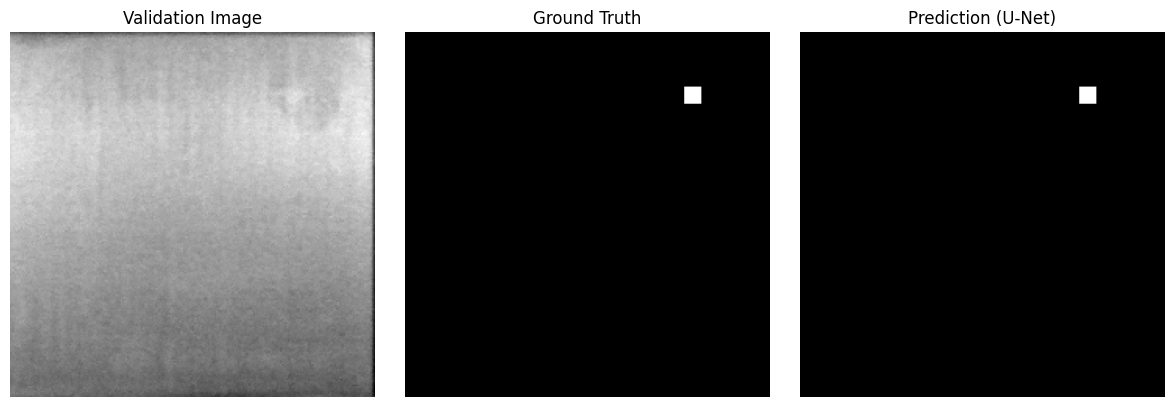

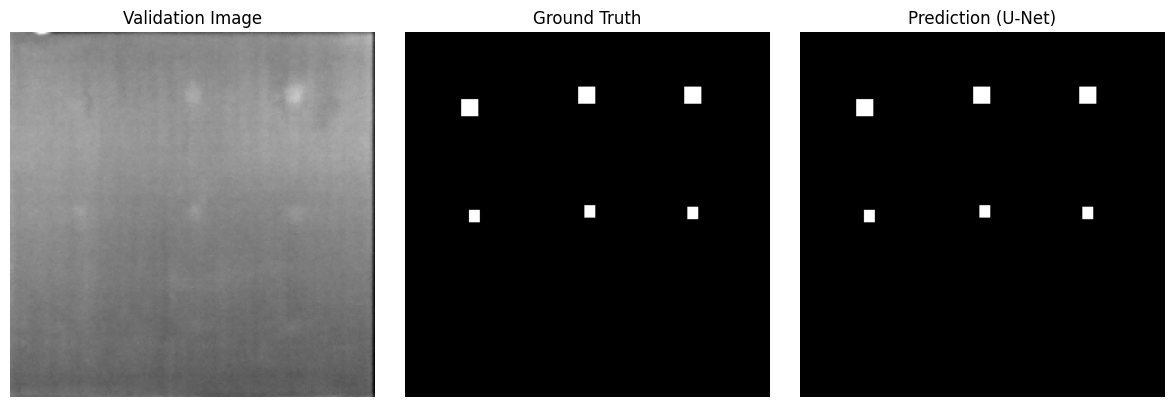

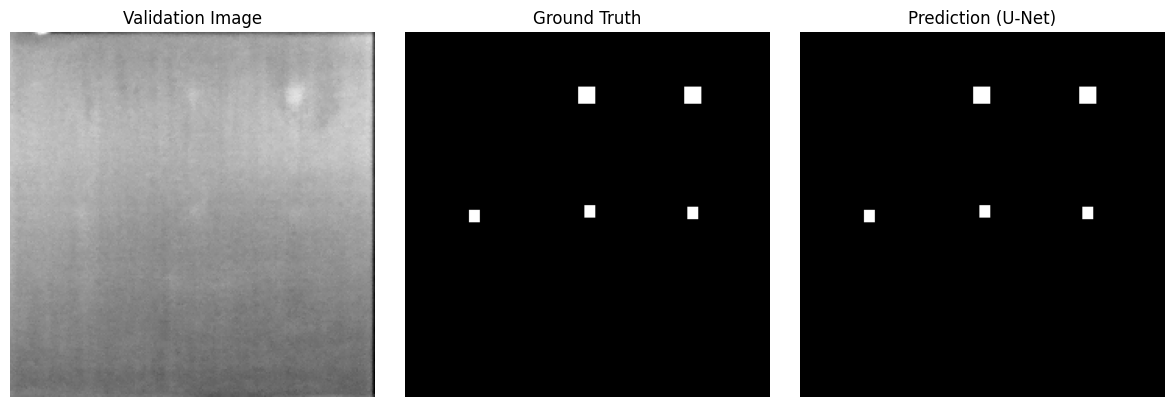

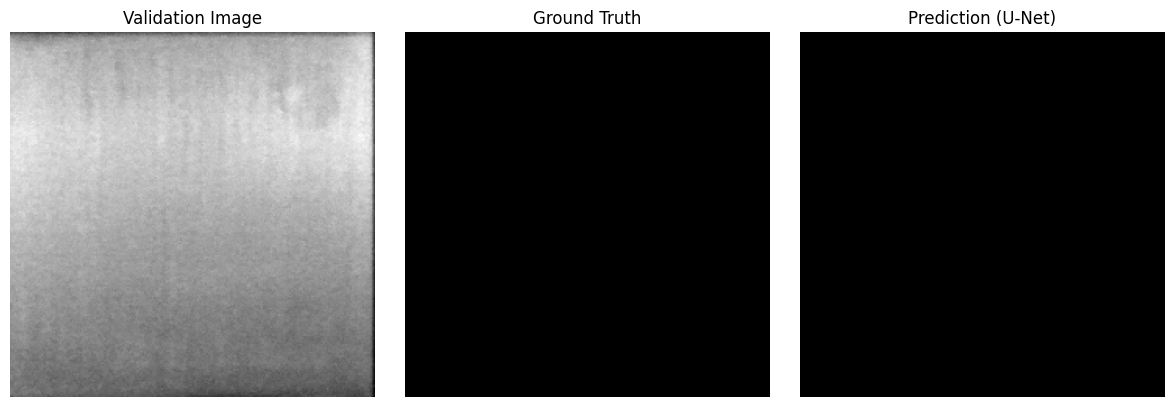

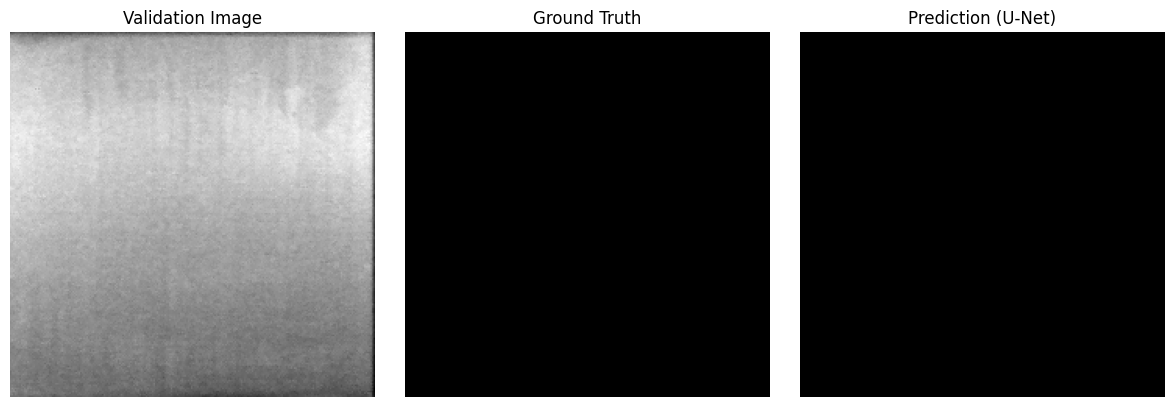

In [11]:
model.load_state_dict(torch.load("/content/drive/MyDrive/spatial-temporal-defect-segmentation/best_unet.pth", map_location=device))
model.eval()

num_images = 5

with torch.no_grad():
    for i in range(num_images):

        img, mask = val_dataset[i]

        img_input = img.unsqueeze(0).to(device)

        output = model(img_input)
        prob = torch.sigmoid(output)
        pred = (prob > 0.5).float()

        img = img.permute(1, 2, 0).cpu().numpy()
        mask = mask.squeeze().cpu().numpy()
        pred = pred.squeeze().cpu().numpy()

        plt.figure(figsize=(12, 4))

        # INPUT
        plt.subplot(1, 3, 1)
        plt.imshow(img)
        plt.title("Validation Image")
        plt.axis("off")

        # GROUND TRUTH
        plt.subplot(1, 3, 2)
        plt.imshow(mask, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        # PREDICTION
        plt.subplot(1, 3, 3)
        plt.imshow(pred, cmap="gray")
        plt.title("Prediction (U-Net)")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

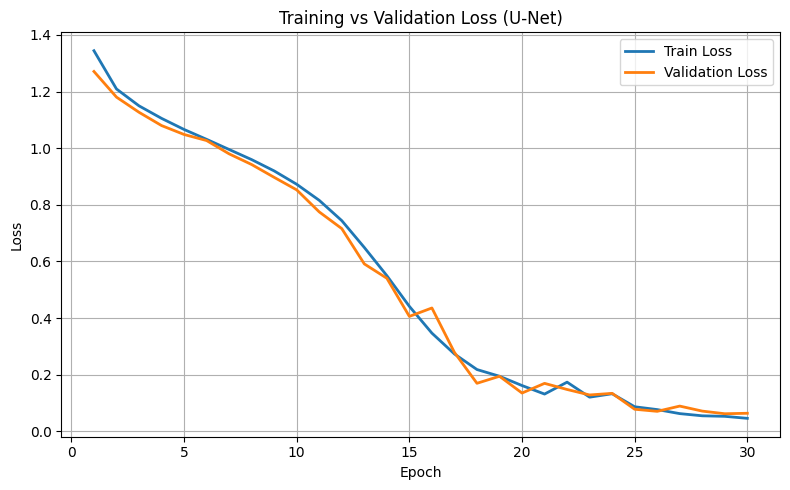

In [12]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, train_losses, label="Train Loss", linewidth=2)
plt.plot(epochs, val_losses, label="Validation Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (U-Net)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()